# Week 11 - Source Separation and Physiological Signal Extraction

## Measured Baseline

กล้องมองเห็นชีพจรได้ เพราะเลือดที่ไหลผ่านผิวหนังทำให้สีของผิวเปลี่ยนไปเล็กน้อยตามจังหวะการเต้นของหัวใจ

ข้อมูลชุดนี้เป็นการบันทึกจริงสองไฟล์จากเหตุการณ์เดียวกัน ยาวประมาณ 120 วินาที
- `rgb_average_25fps.csv` : ค่าเฉลี่ยสี R G B ของผิวในแต่ละเฟรม จากกล้อง fs = 25 Hz ตามด้วยเวลา H M S ของเฟรม
- `pulse_fs100Hz_.txt` : เวลา H M S ตามด้วยสัญญาณ PPG จากเซนเซอร์แบบสัมผัส fs = 100 Hz ใช้เป็น **reference**

ไฟล์ reference **ไม่มีค่า bpm ให้** เราจึงต้องหาจังหวะการเต้นเองจากรูปคลื่น PPG

reference คือสิ่งที่ทำให้ตอบได้ว่าเลขที่เราวัดได้นั้น **ถูกหรือผิด** ไม่ใช่แค่ดูสวย

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal


def time_axis(fs, duration):
    # แกนเวลาแบบเดียวกับที่ใช้มาตั้งแต่สัปดาห์ที่ 1
    return np.arange(0, duration, 1/fs)

def one_sided(x, fs, nfft=None):
    # สเปกตรัมด้านเดียว เขียนเองเหมือนที่ทำมาตั้งแต่สัปดาห์ที่ 6
    n = len(x)
    N = nfft or n
    w = np.hanning(n)                       # taper ลด leakage (สัปดาห์ที่ 6)
    X = np.fft.rfft((x - x.mean()) * w, N)
    freq = np.fft.rfftfreq(N, 1/fs)
    mag = np.abs(X) * 2.0 / np.sum(w)
    return freq, mag

RGB  : 3000 เฟรม  fs = 25 Hz  ยาว 120.00 s
ref  : 12084 ตัวอย่าง  fs = 100 Hz  ยาว 120.84 s
ความเข้มเฉลี่ย  R 161.7   G 146.4   B 151.2


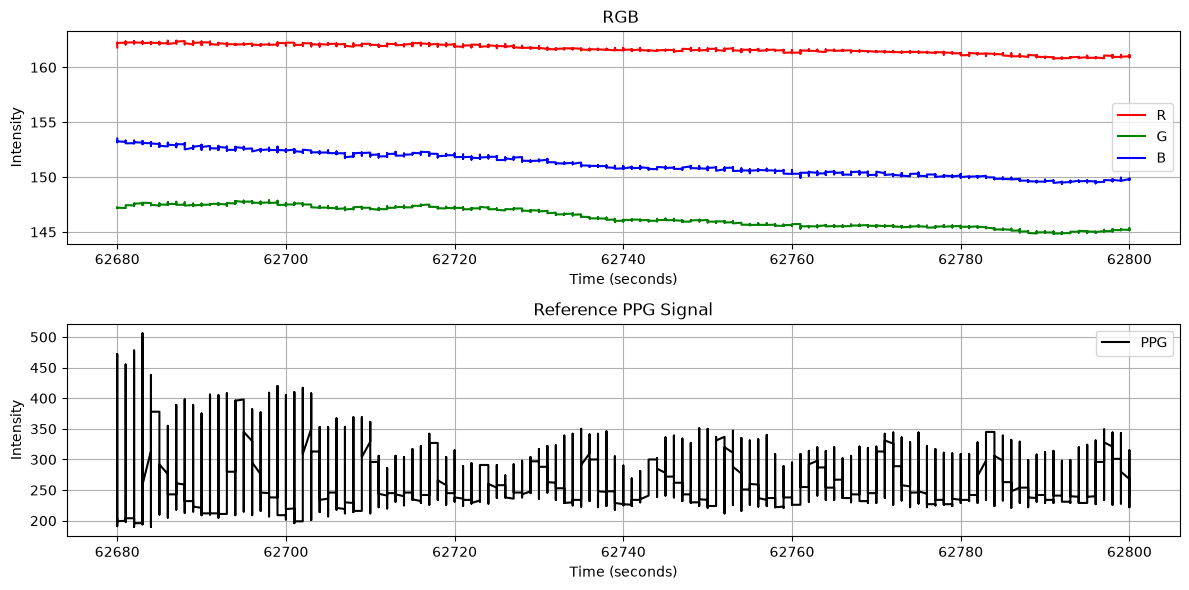

In [2]:
# Example 1.1 : load PPG and iPPG data
FS_RGB = 25          # กล้อง 25 เฟรมต่อวินาที
FS_REF = 100         # เซนเซอร์สัมผัส 100 Hz

RGB_FILE = "rgb_average_25fps.csv"
REF_FILE = "pulse_fs100Hz_.txt"

def load_rgb(path=RGB_FILE):
    # คอลัมน์ R, G, B คือค่าเฉลี่ยสีของผิวในแต่ละเฟรม   H, M, S คือเวลาของเฟรมนั้น
    df = pd.read_csv(path)
    timestamp = df["H"]*3600 + df["M"]*60 + df["S"]  # แปลงเวลาเป็นวินาที
    return df["R"].values, df["G"].values, df["B"].values, timestamp
def load_reference(path=REF_FILE):
    # คั่นด้วยช่องว่าง คอลัมน์คือ H, M, S, PPG  (ไม่มีค่า bpm)
    df = pd.read_csv(path, sep=r"\s+", header=None)
    ppg = df[3].values.astype(float)
    timestamp = df[0]*3600 + df[1]*60 + df[2]  # แปลงเวลาเป็นวินาที
    return ppg, timestamp

R, G, B, TIMESTAMP_RGB = load_rgb()
PPG, TIMESTAMP_PPG = load_reference()
DUR_RGB = len(R)/FS_RGB
DUR_REF = len(PPG)/FS_REF

print("RGB  : %d เฟรม  fs = %.0f Hz  ยาว %.2f s" % (len(R), FS_RGB, DUR_RGB))
print("ref  : %d ตัวอย่าง  fs = %.0f Hz  ยาว %.2f s" % (len(PPG), FS_REF, DUR_REF))
print("ความเข้มเฉลี่ย  R %.1f   G %.1f   B %.1f" % (R.mean(), G.mean(), B.mean()))

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(TIMESTAMP_RGB, R, label="R", color="r")
plt.plot(TIMESTAMP_RGB, G, label="G", color="g")
plt.plot(TIMESTAMP_RGB, B, label="B", color="b")
plt.title("RGB ")
plt.xlabel("Time (seconds)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(TIMESTAMP_PPG, PPG, label="PPG", color="k")
plt.title("Reference PPG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Time alignment

สองไฟล์บันทึกเวลาไว้แค่ระดับ **วินาที** (H M S) ไม่มีมิลลิวินาที

ก่อนจะเทียบกล้องกับ PPG ต้องตอบให้ได้ก่อนว่า ตัวอย่างแต่ละตัวเกิดขึ้นเมื่อไหร่จริง ๆ
1. นับจำนวนตัวอย่างในแต่ละวินาที เพื่อดูว่า fs นิ่งจริงหรือไม่
2. เติมมิลลิวินาทีให้ทุกตัวอย่าง โดยกระจายตัวอย่างของแต่ละวินาทีให้ห่างเท่ากันภายในวินาทีนั้น
3. interpolate ลงบนแกนเวลาที่ห่างเท่ากัน เพราะ filter FFT และ find_peaks ต้องการ fs คงที่ (สัปดาห์ที่ 10)
4. ตรวจผลด้วย cross-correlation

### Crate time axis with common alignment

In [3]:
print(TIMESTAMP_PPG[:200])
# what second, first index see, how many n
sec, first, n = np.unique(TIMESTAMP_PPG, return_index=True, return_counts=True)
print(sec)
print(first)
print(n)

0      62680
1      62680
2      62680
3      62680
4      62680
       ...  
195    62681
196    62681
197    62681
198    62681
199    62681
Length: 200, dtype: int64
[62680 62681 62682 62683 62684 62685 62686 62687 62688 62689 62690 62691
 62692 62693 62694 62695 62696 62697 62698 62699 62700 62701 62702 62703
 62704 62705 62706 62707 62708 62709 62710 62711 62712 62713 62714 62715
 62716 62717 62718 62719 62720 62721 62722 62723 62724 62725 62726 62727
 62728 62729 62730 62731 62732 62733 62734 62735 62736 62737 62738 62739
 62740 62741 62742 62743 62744 62745 62746 62747 62748 62749 62750 62751
 62752 62753 62754 62755 62756 62757 62758 62759 62760 62761 62762 62763
 62764 62765 62766 62767 62768 62769 62770 62771 62772 62773 62774 62775
 62776 62777 62778 62779 62780 62781 62782 62783 62784 62785 62786 62787
 62788 62789 62790 62791 62792 62793 62794 62795 62796 62797 62798 62799
 62800]
[    0   100   200   300   400   500   600   700   800   900  1000  1100
  1200  1300  1400  

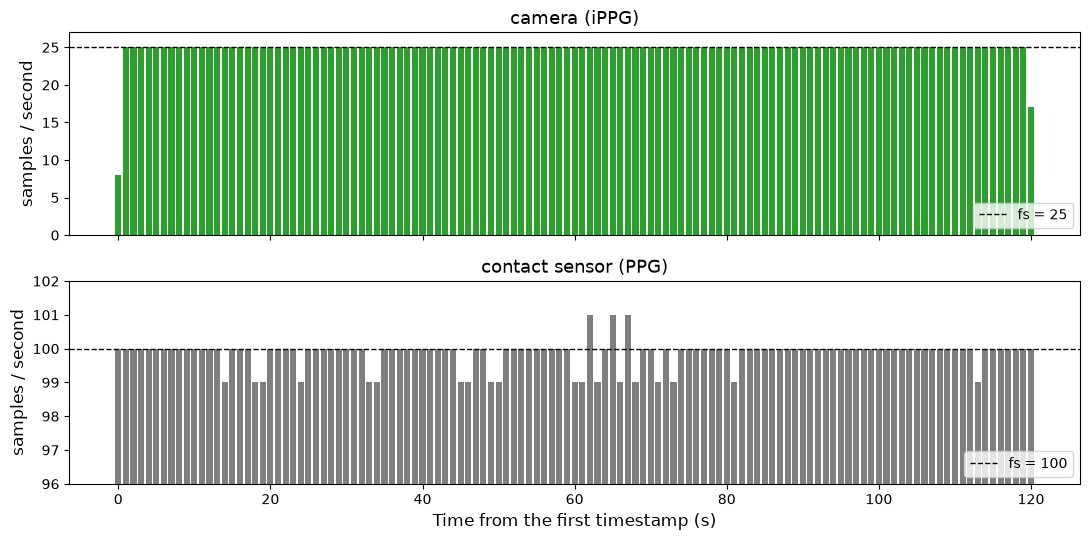

In [4]:
# นับจำนวนตัวอย่างในแต่ละวินาที : fs นิ่งจริงหรือไม่
def count_per_second(timestamp):
    sec, n = np.unique(np.asarray(timestamp), return_counts=True)
    return sec, n

SEC_RGB, N_RGB = count_per_second(TIMESTAMP_RGB)
SEC_PPG, N_PPG = count_per_second(TIMESTAMP_PPG)

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for a, sec, n, fs, name, col in ((ax[0], SEC_RGB, N_RGB, FS_RGB, "camera (iPPG)", "tab:green"),
                                 (ax[1], SEC_PPG, N_PPG, FS_REF, "contact sensor (PPG)", "tab:gray")):
    a.bar(sec - sec[0], n, width=0.8, color=col)
    a.axhline(fs, color="k", ls="--", lw=1, label="fs = %g" % fs)
    a.set_ylabel("samples / second", fontsize=12)
    a.set_title(name, fontsize=13)
    a.legend(loc="lower right")
ax[0].set_ylim(0, 27)
ax[1].set_ylim(96, 102)
ax[1].set_xlabel("Time from the first timestamp (s)", fontsize=12)
plt.tight_layout(); plt.show()

In [5]:
# เติมมิลลิวินาที : กระจายตัวอย่างของแต่ละวินาทีให้ห่างเท่ากันภายในวินาทีนั้น
def add_ms(timestamp, fs):
    sec = np.asarray(timestamp, dtype=float)
    _, first, n = np.unique(sec, return_index=True, return_counts=True)
    k = np.arange(len(sec)) - np.repeat(first, n)      # ลำดับของตัวอย่างภายในวินาทีของมัน
    frac = k / np.repeat(n, n)                         # วินาทีเต็ม : กระจายเท่า ๆ กัน
    if n[0] < fs:                                      # วินาทีแรกไม่เต็ม : เริ่มกลางวินาที ชิดท้าย
        frac[:n[0]] = (fs - n[0] + k[:n[0]]) / fs
    if n[-1] < fs:                                     # วินาทีสุดท้ายไม่เต็ม : หยุดกลางวินาที ชิดหน้า
        frac[-n[-1]:] = k[-n[-1]:] / fs
    return sec + frac

T_RGB = add_ms(TIMESTAMP_RGB, FS_RGB)
T_PPG = add_ms(TIMESTAMP_PPG, FS_REF)
print(T_RGB[:FS_RGB])
print(T_PPG[:FS_REF])

[62680.68 62680.72 62680.76 62680.8  62680.84 62680.88 62680.92 62680.96
 62681.   62681.04 62681.08 62681.12 62681.16 62681.2  62681.24 62681.28
 62681.32 62681.36 62681.4  62681.44 62681.48 62681.52 62681.56 62681.6
 62681.64]
[62680.   62680.01 62680.02 62680.03 62680.04 62680.05 62680.06 62680.07
 62680.08 62680.09 62680.1  62680.11 62680.12 62680.13 62680.14 62680.15
 62680.16 62680.17 62680.18 62680.19 62680.2  62680.21 62680.22 62680.23
 62680.24 62680.25 62680.26 62680.27 62680.28 62680.29 62680.3  62680.31
 62680.32 62680.33 62680.34 62680.35 62680.36 62680.37 62680.38 62680.39
 62680.4  62680.41 62680.42 62680.43 62680.44 62680.45 62680.46 62680.47
 62680.48 62680.49 62680.5  62680.51 62680.52 62680.53 62680.54 62680.55
 62680.56 62680.57 62680.58 62680.59 62680.6  62680.61 62680.62 62680.63
 62680.64 62680.65 62680.66 62680.67 62680.68 62680.69 62680.7  62680.71
 62680.72 62680.73 62680.74 62680.75 62680.76 62680.77 62680.78 62680.79
 62680.8  62680.81 62680.82 62680.83 6268

In [8]:
# interpolate ลงบนแกนเวลาที่ห่างเท่ากัน (สัปดาห์ที่ 10) บนนาฬิกาเดียวกัน
def to_uniform(t, x, fs):
    t_new = np.arange(t[0], t[-1] + 1e-9, 1/fs)
    return t_new, np.interp(t_new, t, x) #can be use resampling_poly

# interpolate ลง fs เดิมของแต่ละสัญญาณ
T_RGB_OWN, R_OWN = to_uniform(T_RGB, R, FS_RGB)
T_PPG_OWN, PPG_OWN = to_uniform(T_PPG, PPG, FS_REF)

print(len(R_OWN), len(PPG_OWN))
print(T_PPG_OWN[:5])
print(T_RGB_OWN[:5])

3000 12100
[62680.   62680.01 62680.02 62680.03 62680.04]
[62680.68 62680.72 62680.76 62680.8  62680.84]


In [9]:
# interpolate ลง fs เดียวกัน
FS_TARGET = 100
T_RGB_U, R_U = to_uniform(T_RGB, R, FS_TARGET)
_, G_U = to_uniform(T_RGB, G, FS_TARGET)
_, B_U = to_uniform(T_RGB, B, FS_TARGET)
T_PPG_U, PPG_U = to_uniform(T_PPG, PPG, FS_TARGET)

print(len(PPG_U))
print(len(R_U))

print(T_PPG_U[:FS_TARGET])
print(T_RGB_U[:FS_TARGET])


12100
11997
[62680.   62680.01 62680.02 62680.03 62680.04 62680.05 62680.06 62680.07
 62680.08 62680.09 62680.1  62680.11 62680.12 62680.13 62680.14 62680.15
 62680.16 62680.17 62680.18 62680.19 62680.2  62680.21 62680.22 62680.23
 62680.24 62680.25 62680.26 62680.27 62680.28 62680.29 62680.3  62680.31
 62680.32 62680.33 62680.34 62680.35 62680.36 62680.37 62680.38 62680.39
 62680.4  62680.41 62680.42 62680.43 62680.44 62680.45 62680.46 62680.47
 62680.48 62680.49 62680.5  62680.51 62680.52 62680.53 62680.54 62680.55
 62680.56 62680.57 62680.58 62680.59 62680.6  62680.61 62680.62 62680.63
 62680.64 62680.65 62680.66 62680.67 62680.68 62680.69 62680.7  62680.71
 62680.72 62680.73 62680.74 62680.75 62680.76 62680.77 62680.78 62680.79
 62680.8  62680.81 62680.82 62680.83 62680.84 62680.85 62680.86 62680.87
 62680.88 62680.89 62680.9  62680.91 62680.92 62680.93 62680.94 62680.95
 62680.96 62680.97 62680.98 62680.99]
[62680.68 62680.69 62680.7  62680.71 62680.72 62680.73 62680.74 62680.75
 

In [10]:
# Example 1.2 : Time alignment and common fs
# ตัดช่วงต้นและท้ายที่ไม่มีข้อมูลซ้อนกัน แล้วจัดทุกสัญญาณบนแกนเวลาเดียวกัน
# use the time from each signal to find the value
T_START = max(T_RGB_U[0], T_PPG_U[0])
T_END = min(T_RGB_U[-1], T_PPG_U[-1])
print(T_START, T_END)

# สร้างแกนเวลาร่วมกัน (T_C) ห่างกัน 1/FS_TARGET พอดี
n_c = int(round((T_END - T_START) * FS_TARGET)) + 1
T_C = T_START + np.arange(n_c) / FS_TARGET

R_C = np.interp(T_C, T_RGB_U, R_U)
G_C = np.interp(T_C, T_RGB_U, G_U)
B_C = np.interp(T_C, T_RGB_U, B_U)
PPG_C = np.interp(T_C, T_PPG_U, PPG_U)

print(len(T_C), len(R_C), len(G_C), len(B_C), len(PPG_C))

62680.68 62800.64000002444
11997 11997 11997 11997 11997


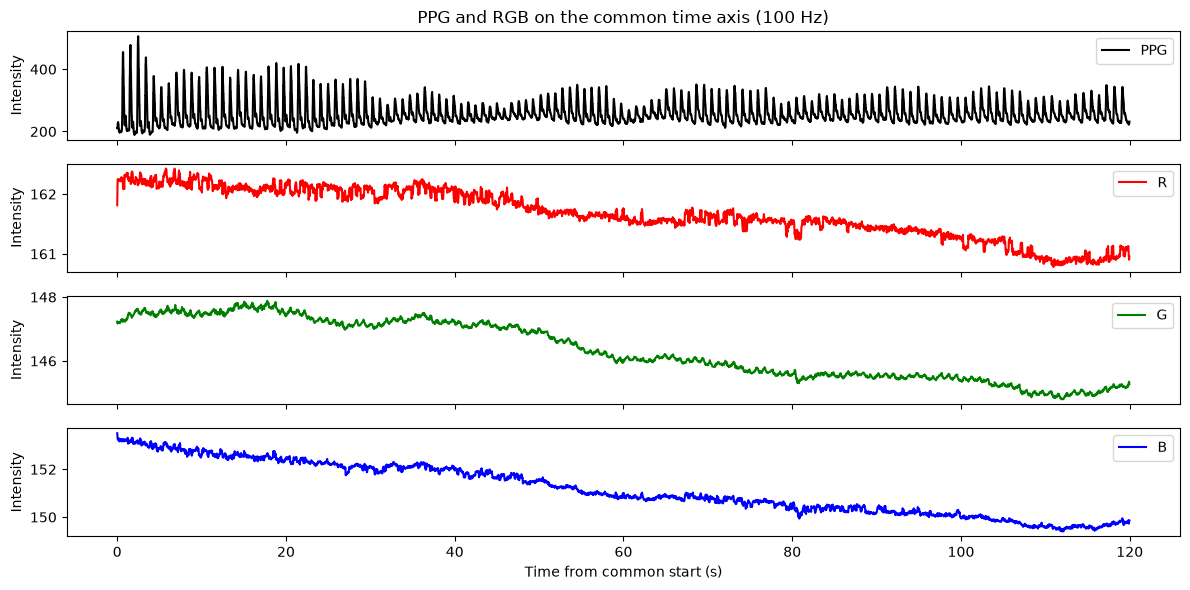

In [11]:
fig, ax = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
for a, x, name, col in zip(ax, (PPG_C, R_C, G_C, B_C), ("PPG", "R", "G", "B"), ("k", "r", "g", "b")):
    a.plot(T_C - T_C[0], x, label=name, color=col)
    a.set_ylabel("Intensity")
    a.legend(loc="upper right")
ax[0].set_title("PPG and RGB on the common time axis (%d Hz)" % FS_TARGET)
ax[-1].set_xlabel("Time from common start (s)")
plt.tight_layout()
plt.show()

In [12]:
# what we're doing is adding ms to the signal
# after insert, cut or interpolate to have the same signal


### Do first measurement

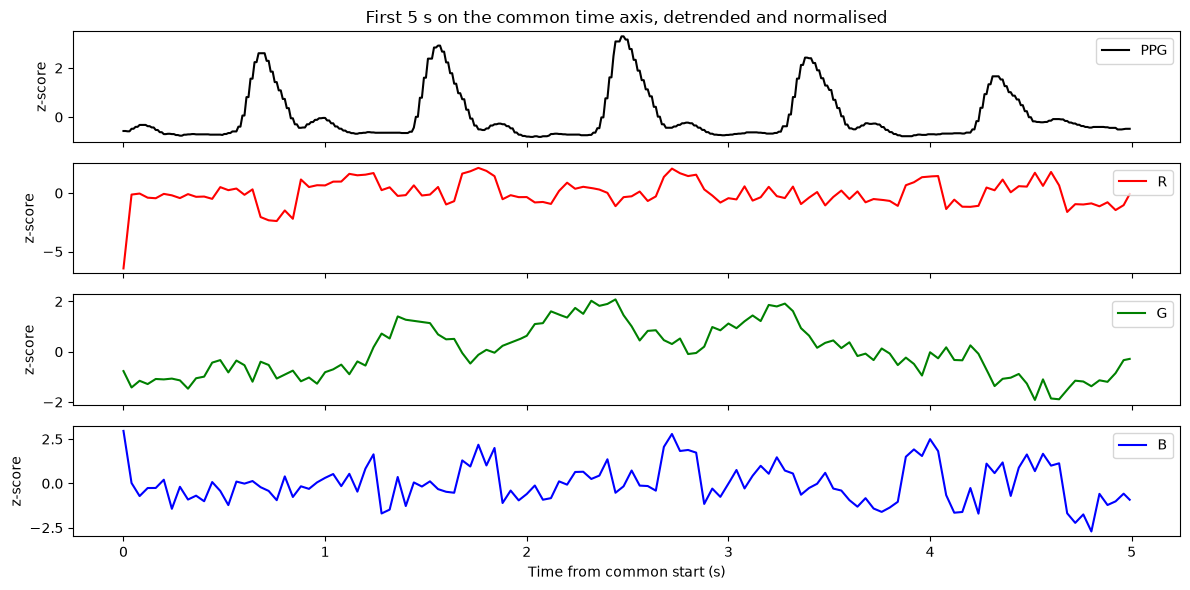

In [13]:
# Example 1.3 : แสดงการเปรียบเทียบสัญญาณ PPG และ iPPG หลังจาก detrend และ normalise
def normalize_detrend(x):
    y = signal.detrend(x)             # ลบเทรนด์เชิงเส้นออกก่อน
    return (y - y.mean()) / y.std()   # แล้วค่อยทำให้ std = 1

duration = 5
n_w = FS_TARGET * duration # 100 * 5
T_window = T_C[:n_w] - T_C[0]         # ทุกสัญญาณใช้แกนเวลาร่วม T_C
PPG_window = normalize_detrend(PPG_C[:n_w])
R_window = normalize_detrend(R_C[:n_w])
G_window = normalize_detrend(G_C[:n_w])
B_window = normalize_detrend(B_C[:n_w])

fig, ax = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
for a, x, name, col in zip(ax, (PPG_window, R_window, G_window, B_window),
                           ("PPG", "R", "G", "B"), ("k", "r", "g", "b")):
    a.plot(T_window, x, label=name, color=col)
    a.set_ylabel("z-score")
    a.legend(loc="upper right")
ax[0].set_title("First %d s on the common time axis, detrended and normalised" % duration)
ax[-1].set_xlabel("Time from common start (s)")
plt.tight_layout()
plt.show()

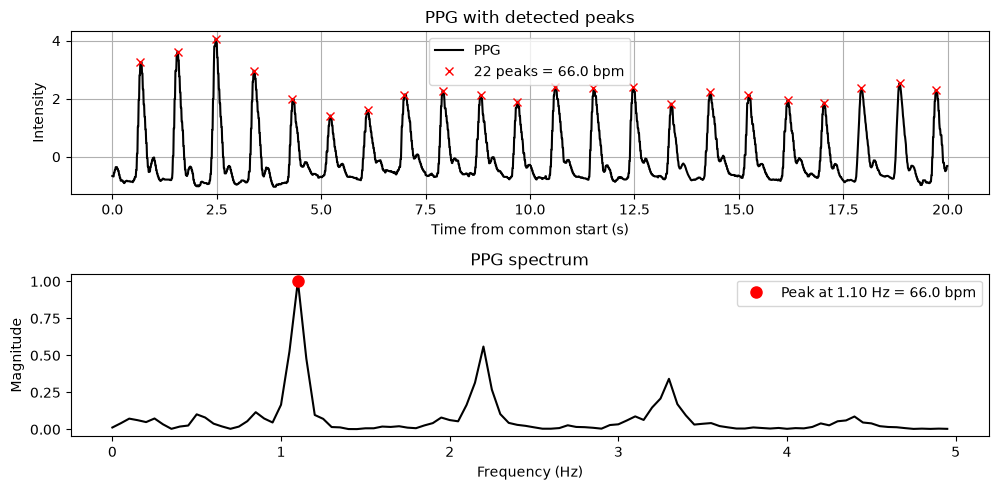

In [14]:
# วัดความถี่สัญญาณ PPG ด้วย peak counting และ fft
duration = 20
n_w = FS_TARGET * duration
T_window = T_C[:n_w] - T_C[0]
PPG_window = normalize_detrend(PPG_C[:n_w])

peaks, _ = signal.find_peaks(PPG_window, distance=60, height=1) 
plt.figure(figsize=(10, 5))
plt.subplot(2,1,1)
plt.plot(T_window, PPG_window, label="PPG", color="k")
plt.plot(T_window[peaks], PPG_window[peaks], "x", label=f"{len(peaks)} peaks = {len(peaks)/duration*60} bpm", color="r")
plt.title("PPG with detected peaks")
plt.xlabel("Time from common start (s)")
plt.ylabel("Intensity")
plt.legend()
plt.grid()
plt.subplot(2,1,2)
spectrum_freq, spectrum_mag = one_sided(PPG_window, FS_TARGET)
spectrum_freq = spectrum_freq[:100]
spectrum_mag = spectrum_mag[:100]
plt.plot(spectrum_freq, spectrum_mag, color="k")
i = np.argmax(spectrum_mag)
plt.plot(spectrum_freq[i], spectrum_mag[i], "ro", ms=8, label=f"Peak at {spectrum_freq[i]:.2f} Hz = {spectrum_freq[i]*60:.1f} bpm")
plt.title("PPG spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.tight_layout()
plt.show()

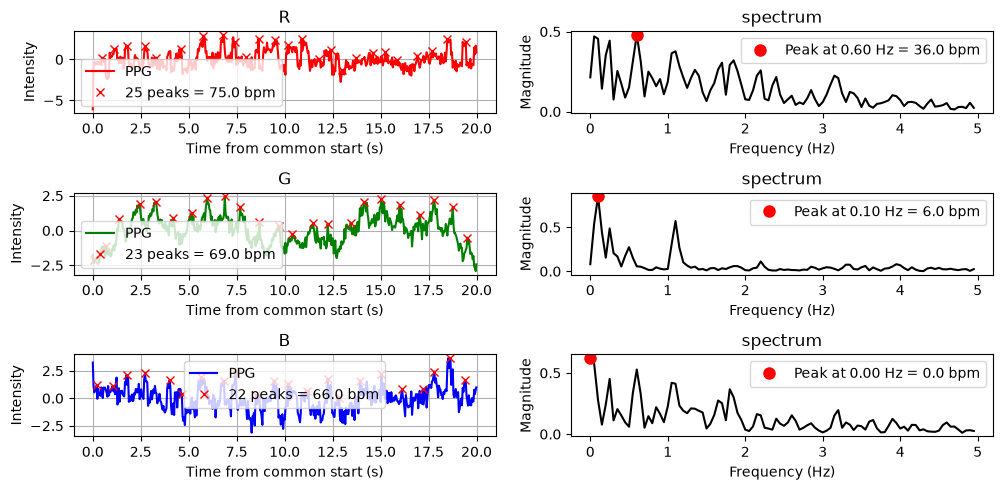

In [15]:
duration = 20
n_w = FS_TARGET * duration
T_window = T_C[:n_w] - T_C[0]
R_window = normalize_detrend(R_C[:n_w])
G_window = normalize_detrend(G_C[:n_w])
B_window = normalize_detrend(B_C[:n_w])
plt.figure(figsize=(10, 5))
plot_index = 1
for trace, name in zip([R_window, G_window, B_window], ["R", "G", "B"]):
    peaks, _ = signal.find_peaks(trace, distance=60) 

    plt.subplot(3,2,plot_index)
    plot_index += 1
    plt.plot(T_window, trace, label="PPG", color=name.lower())
    plt.plot(T_window[peaks], trace[peaks], "x", label=f"{len(peaks)} peaks = {len(peaks)/duration*60} bpm", color="r")
    plt.title(name)
    plt.xlabel("Time from common start (s)")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid()
    plt.subplot(3,2,plot_index)
    plot_index += 1
    spectrum_freq, spectrum_mag = one_sided(trace, FS_TARGET)
    spectrum_freq = spectrum_freq[:100]
    spectrum_mag = spectrum_mag[:100]
    plt.plot(spectrum_freq, spectrum_mag, color="k")
    i = np.argmax(spectrum_mag)
    plt.plot(spectrum_freq[i], spectrum_mag[i], "ro", ms=8, label=f"Peak at {spectrum_freq[i]:.2f} Hz = {spectrum_freq[i]*60:.1f} bpm")
    plt.title("spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
plt.tight_layout()
plt.show()


## Exercise 1

สัญญาณจากกล้องมีสิ่งรบกวนมาก ทั้งแสงที่เปลี่ยนช้า ๆ และสัญญาณรบกวนความถี่สูง ลองกรองให้เหลือเฉพาะย่านชีพจร 0.7 ถึง 3.0 Hz

1. กรอง PPG, R, G, B ด้วยตัวกรอง **โดเมนเวลา** 1 แบบ เช่น moving average, Savitzky-Golay
2. กรองสัญญาณชุดเดิมด้วยตัวกรอง **โดเมนความถี่** : FFT -> ตั้งค่าที่อยู่นอกย่าน 0.7 ถึง 3.0 Hz ให้เป็นศูนย์
3. วาดสัญญาณก่อนและหลังกรอง ทั้งรูปคลื่นและสเปกตรัม
4. วัดชีพจรใน 20 วินาทีแรกใหม่ ด้วยการนับยอดและ FFT แล้วเทียบกับ PPG
5. ตอบว่าการกรองช่วยวิธีไหน และช่วยช่องสีไหนได้บ้าง

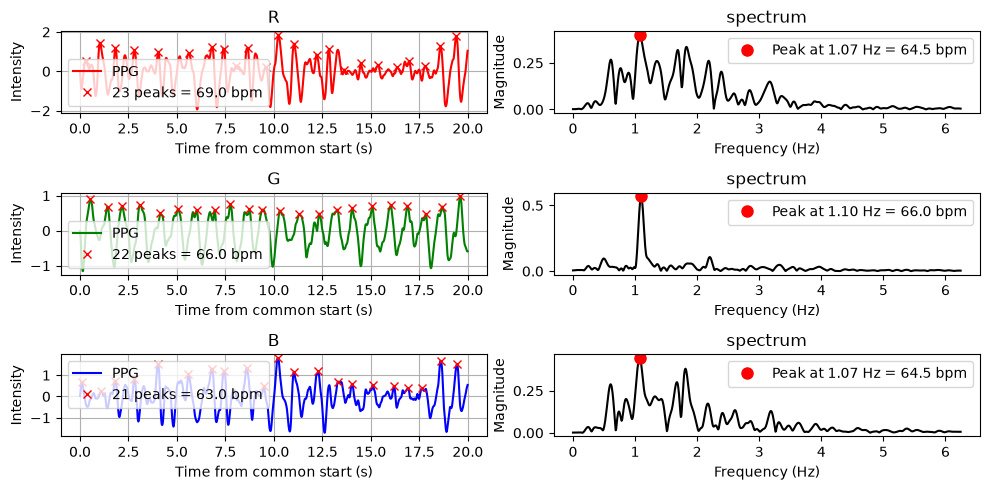

In [58]:
# Ex1 : กรองในโดเมนเวลาและโดเมนความถี่ แล้ววัดชีพจรใน 20 วินาทีแรกใหม่
from scipy import signal
# sg filter : signal.savgol_filter
def moving_average(y, M):
    return np.convolve(y, np.ones(M) / M, mode="same")
# butterworth : b, a = signal.butter(4, 20, fs=fs, btype="lowpass")
# y = signal.lfilter(b, a, x)

duration = 20
n_w = FS_TARGET * duration
T_window = T_C[:n_w] - T_C[0]

PPG_window = normalize_detrend(PPG_C[:n_w])
R_window = normalize_detrend(R_C[:n_w])
G_window = normalize_detrend(G_C[:n_w])
B_window = normalize_detrend(B_C[:n_w])

# Your code
# R_filter = moving_average(R_window, 51)

'''
R_filter = signal.savgol_filter(R_window, 21, 2)
b, a = signal.butter(4, [0.7, 3], fs = FS_TARGET, btype = "bandpass")
R_filter = signal.lfilter(b, a, R_window)

plt.figure(figsize=(15, 5))
# plt.subplot(1, 2, 1); plt.plot(T_window, R_window, label = "R", color = "r")
plt.subplot(4, 2, 1); plt.plot(T_window, R_filter, label = "R", color = 'r')


spectrum_freq, spectrum_mag = one_sided(R_filter, FS_TARGET)
spectrum_freq = spectrum_freq[:100]
spectrum_mag = spectrum_mag[:100]
plt.subplot(4, 2, 2); plt.plot(spectrum_freq, spectrum_mag, color="k")
'''
plt.figure(figsize=(10, 5))
plot_index = 1
for trace, name in zip([R_window, G_window, B_window], ["R", "G", "B"]):
    # trace = signal.savgol_filter(trace, 21, 2)
    b, a = signal.butter(2, [0.7, 3], fs = FS_TARGET, btype = "bandpass")
    trace = signal.lfilter(b, a, trace)
    peaks, _ = signal.find_peaks(trace, distance=60)

    plt.subplot(3,2,plot_index)
    plot_index += 1
    plt.plot(T_window, trace, label="PPG", color=name.lower())
    plt.plot(T_window[peaks], trace[peaks], "x", label=f"{len(peaks)} peaks = {len(peaks)/duration*60} bpm", color="r")
    plt.title(name)
    plt.xlabel("Time from common start (s)")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid()
    plt.subplot(3,2,plot_index)
    plot_index += 1
    spectrum_freq, spectrum_mag = one_sided(trace, FS_TARGET, len(trace)*8)
    spectrum_freq = spectrum_freq[:1000]
    spectrum_mag = spectrum_mag[:1000]
    plt.plot(spectrum_freq, spectrum_mag, color="k")
    i = np.argmax(spectrum_mag)
    plt.plot(spectrum_freq[i], spectrum_mag[i], "ro", ms=8, label=f"Peak at {spectrum_freq[i]:.2f} Hz = {spectrum_freq[i]*60:.1f} bpm")
    plt.title("spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
plt.tight_layout()
plt.savefig("670710258.png")
plt.show()

## Exercise 2

ตอนนี้เราวัดชีพจรของสัญญาณ 1 ช่วงได้แล้ว ต่อไปจะวัดทั้งเส้นด้วยการแบ่งหน้าต่าง (framing)

1. กรองสัญญาณด้วยตัวกรองจาก Exercise 1
2. แบ่งทุกสัญญาณเป็นหน้าต่างละ **20 วินาที** เลื่อนทีละ **10 วินาที** (ซ้อนทับกัน 10 วินาที)
3. หาชีพจรของทุกหน้าต่างด้วย FFT จากยอดสูงสุดในย่าน 0.7 ถึง 3.0 Hz ทั้ง PPG, R, G และ B
4. วาดชีพจรของแต่ละหน้าต่างเทียบกับเวลา ให้ PPG เป็นเส้นอ้างอิง
5. คำนวณ MAE ของแต่ละช่องสีเทียบกับ PPG แล้วตอบว่าช่องไหนใกล้ PPG ที่สุด

In [59]:
# Ex2 : แบ่งหน้าต่าง 20 วินาที เลื่อนทีละ 10 วินาที แล้ววัดชีพจรทุกหน้าต่าง
duration = 20
P_SIZE = duration*FS_TARGET
P1 = 0
P2 = P_SIZE
P_STEP = int(0.5*P_SIZE)
N_WINDOW = int(1 + np.floor( (len(PPG_C)-P_SIZE)/P_STEP ) )
HR = []

# Your code
for i in range(N_WINDOW):
    PPG_window = normalize_detrend(PPG_C[P1:P2])
    R_window = normalize_detrend(R_C[P1:P2])
    G_window = normalize_detrend(G_C[P1:P2])
    B_window = normalize_detrend(B_C[P1:P2])
    HR_window = []
    for trace, name in zip([PPG_window, R_window, G_window, B_window], ["PPG", "R", "G", "B"]):
        trace = signal.savgol_filter(trace, 41, 4)
        b, a = signal.butter(2, [0.7, 3], fs = FS_TARGET, btype = "bandpass")
        trace = signal.lfilter(b, a, trace)
        peaks, _ = signal.find_peaks(trace, distance=60)
        spectrum_freq, spectrum_mag = one_sided(trace, FS_TARGET, len(trace)*8)
        spectrum_freq = spectrum_freq[:100]
        spectrum_mag = spectrum_mag[:100]
        i = np.argmax(spectrum_mag)
        bpm = spectrum_freq[i]*60
        HR_window.append(bpm)
    HR.append(HR_window)
    P1 += P_STEP
    P2 += P_STEP
HR = np.array(HR)
print(HR)
ref_HR = HR[:, 0]
R_HR = HR[: , 3]
# print(np.mean(np.abs(ref_HR - R_HR)))

[[30.75  36.75  29.625 36.375]
 [32.25  37.125 35.25  37.125]
 [33.75  37.125 33.    29.625]
 [34.125 37.125 16.5   37.125]
 [33.    34.875 17.625 18.   ]
 [32.625 30.75  16.125 30.75 ]
 [30.75  37.125 31.875 37.125]
 [29.625 37.125 37.125 37.125]
 [30.375 37.125 34.5   37.125]
 [30.375 31.125 32.25  36.375]]


## The Signal Mixture

สามช่องสีมองหน้าคนเดียวกัน ชีพจรเดียวกัน แต่ให้คำตอบไม่เหมือนกัน

หัวข้อนี้หาว่าแต่ละช่องสีประกอบด้วยอะไร แล้วเขียนเป็นแบบจำลองการผสม (mixing model) **x[n] = A s[n]**

### Covariance and point cloud

ตรวจคำตอบ Exercise 3 ด้วย `np.cov` แล้ววาด point cloud ของแต่ละคู่สัญญาณ

In [66]:
# Example 4.1 : ตรวจคำตอบ Exercise 3 ด้วย np.cov
x1 = np.array([1, 2, 3, 4, 5, 5, 6, 7, 8, 9])
x2 = np.array([0, 2, 4, 6, 8, 8, 8, 8, 8, 8])
x3 = np.array([5, 4, 3, 2, 1, 1, 2, 3, 4, 5])
X = np.array([x1, x2, x3])                 # แถวละ 1 สัญญาณ

# bias=True หารด้วย N แบบในสไลด์ (ค่าเริ่มต้นของ np.cov หารด้วย N-1)
C = np.cov(X, bias=True)
print("mean :", X.mean(axis=1))
print(x2 - x2.mean())
print("C :\n", C)
assert np.allclose(C, [[6, 6, 0], [6, 8, -2], [0, -2, 2]])

print(np.cov(x1, x2))

mean : [5. 6. 3.]
[-6. -4. -2.  0.  2.  2.  2.  2.  2.  2.]
C :
 [[ 6.  6.  0.]
 [ 6.  8. -2.]
 [ 0. -2.  2.]]
[[6.66666667 6.66666667]
 [6.66666667 8.88888889]]


In [74]:
x1c = x1 - x1.mean()
x2c = x2 - x2.mean()
x2c = x3 - x3.mean()
print(np.sum(x2*x3)/10)

16.0


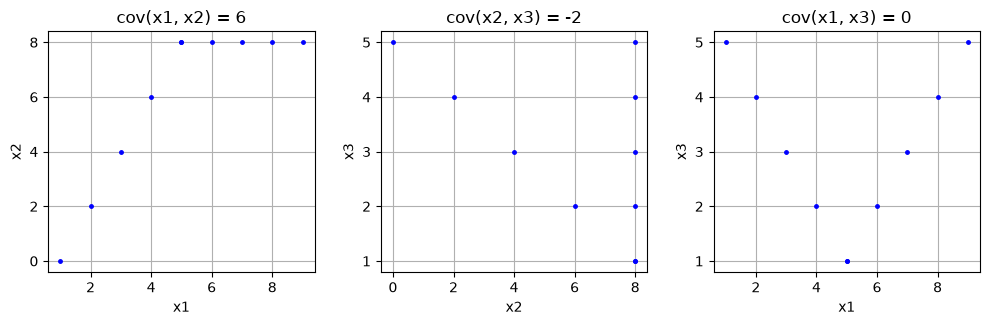

In [72]:
# Example 4.2 point cloud : จับคู่ค่าของสองสัญญาณที่ n เดียวกัน แล้ว plot เป็นจุด
def plot_point_cloud(X, names, step=1, title=""):
    # X : แถวละ 1 สัญญาณ   step : ใช้ทุก step ตัวอย่าง ให้กราฟไม่หนักเกินไป
    C = np.cov(X, bias=True)
    fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
    for a, (i, j) in zip(ax, [(0, 1), (1, 2), (0, 2)]):
        a.plot(X[i, ::step], X[j, ::step], ".", ms=5, color="b")
        a.set_xlabel(names[i])
        a.set_ylabel(names[j])
        a.set_title(f"cov({names[i]}, {names[j]}) = {round(C[i, j], 3) + 0.0:g}")
        a.grid()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_point_cloud(X, ["x1", "x2", "x3"])

### Signal mixture

สร้างแหล่งกำเนิด 3 ตัวที่รู้คำตอบ : sine 1 Hz, square 0.3 Hz และ noise

แล้วผสมด้วยเมทริกซ์ A ที่รู้ค่า **x = A s** ได้สัญญาณผสม 3 ช่อง เหมือนกล้องผสมชีพจร แสง และ noise ลงใน R, G, B

ใช้สัญญาณชุดนี้ตลอดทั้งสัปดาห์ : covariance -> PCA -> whitening -> ICA

In [ ]:
# Example 4.3 : สัญญาณผสม 3 ช่อง  x = A s
def plot_signals(t, X, names, title=""):
    # X : แถวละ 1 สัญญาณ วาดเรียงกันลงมา
    fig, ax = plt.subplots(len(X), 1, figsize=(10, 4), sharex=True)
    for a, x, name, col in zip(ax, X, names, "rgbkm"):
        a.plot(t, x, color=col)
        a.set_ylabel(name)
        a.grid()
    ax[0].set_title(title)
    ax[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


T_MIX = np.arange(0, 10, 1/100)
rng_mix = np.random.default_rng(0)
S_MIX = np.vstack([np.sin(2*np.pi*1.0*T_MIX),               # s1 : sine 1 Hz
                   signal.square(2*np.pi*0.3*T_MIX),        # s2 : square 0.3 Hz
                   rng_mix.normal(0, 0.5, len(T_MIX))])     # s3 : noise
A_MIX = np.array([[1.0, 0.5, 0.3],
                  [0.6, 1.0, 0.4],
                  [0.4, 0.7, 1.0]])
X_MIX = A_MIX @ S_MIX                                       # แถวละ 1 ช่อง เหมือน R, G, B

plot_signals(T_MIX, S_MIX, ["s1", "s2", "s3"], "sources s : sine, square, noise")
plot_signals(T_MIX, X_MIX, ["x1", "x2", "x3"], "mixtures x = A s")

In [ ]:
# covariance และ point cloud : ก่อนผสม (s) และหลังผสม (x)
print("covariance ของแหล่งกำเนิด s :\n", np.round(np.cov(S_MIX, bias=True), 2))
print("covariance ของสัญญาณผสม x :\n", np.round(np.cov(X_MIX, bias=True), 2))
plot_point_cloud(S_MIX, ["s1", "s2", "s3"], step=2, title="sources s")
plot_point_cloud(X_MIX, ["x1", "x2", "x3"], step=2, title="mixtures x")

แหล่งกำเนิดทั้ง 3 ตัวแทบไม่สัมพันธ์กัน : covariance นอกแนวทแยงใกล้ศูนย์ และ point cloud ไม่เอียง

หลังผสม ทุกช่องมีแหล่งกำเนิดชุดเดียวกันปนอยู่ ต่างกันแค่สัดส่วน ทุกช่องจึงขึ้นลงไปด้วยกัน : covariance เป็นบวกทุกคู่ และ point cloud เอียงเป็นแนวทแยง

covariance จึงเป็นร่องรอยของการผสม แต่ยังไม่บอกว่าแหล่งกำเนิดคืออะไร

## Exercise 4

ทำแบบเดียวกับ Example 4.3 กับสัญญาณจริง R, G, B ของ iPPG (แกนเวลาร่วม 100 Hz : `R_C`, `G_C`, `B_C`)

1. รวม R, G, B เป็น array 3 แถว แล้วหา covariance matrix ด้วย `np.cov(..., bias=True)` 
2. วาด point cloud ของคู่ R-G, G-B และ R-B ด้วย `plot_point_cloud`
3. ทำข้อ 1 และ 2 ซ้ำกับสัญญาณที่กรองย่าน 0.7 ถึง 3 Hz แล้ว (`prep` ใน cell ข้างล่าง)
4. ตอบว่าหลังกรอง ความสัมพันธ์และรูปร่างของ point cloud เปลี่ยนไปอย่างไร และเพราะอะไร

In [ ]:
# ตัวช่วยสำหรับสัญญาณจริง : รวมขั้นตอนที่ทำซ้ำใน Exercise 1 และ 2 เป็นฟังก์ชัน
BAND = (0.7, 3.0)                          # ย่านชีพจร 42 ถึง 180 bpm
WIN, STEP = 20*FS_TARGET, 10*FS_TARGET     # หน้าต่าง 20 s เลื่อนทีละ 10 s

def prep(x):
    # detrend + normalise -> Savitzky-Golay -> band-pass 0.7 ถึง 3 Hz (ขั้นเดียวกับ Exercise 2)
    y = signal.savgol_filter(normalize_detrend(x), 21, 2)
    b, a = signal.butter(2, BAND, fs=FS_TARGET, btype="bandpass")
    return signal.lfilter(b, a, y)
def peak_bpm(x, fs=FS_TARGET):
    # ชีพจรจากยอดสูงสุดของสเปกตรัม (แบบ Exercise 2)
    freq, mag = one_sided(x, fs)
    return freq[np.argmax(mag)] * 60
def frame_starts(n, win=WIN, step=STEP):
    # ตำแหน่งเริ่มของทุกหน้าต่าง (จำนวนหน้าต่างเท่ากับ Exercise 2)
    # n คือ ความยาวของสัญญาณ   win คือ ความยาวหน้าต่าง   step คือ การเลื่อนหน้าต่าง
    return list(range(0, n - win + 1, step))
def rgb_window(s):
    # R, G, B ที่กรองแล้ว ของหน้าต่างที่เริ่มที่ตัวอย่าง s : แถวละ 1 ช่อง
    return np.vstack([prep(c[s:s + WIN]) for c in (R_C, G_C, B_C)])

In [ ]:
# Exercise 4 : covariance ของ R, G, B ก่อนและหลังกรอง
# ใช้ตัวแปร R_C, G_C, B_C ที่ได้จากการ align และ interpolate แล้ว
# your code


In [ ]:
# point cloud ก่อนและหลังกรอง (ใช้ทุก 10 ตัวอย่าง)
# your code


### PCA as a tool

มองสัญญาณหลายช่องเป็นตารางข้อมูล : แถว = เวลา n, คอลัมน์ = ช่องสัญญาณ

PCA รับตารางนี้ แล้วให้คอลัมน์ใหม่ PC1, PC2, PC3 ที่เรียงตามความแปรปรวน พร้อมสูตรผสม (น้ำหนัก) ของแต่ละคอลัมน์ ลองกับสัญญาณผสมของ Example 4.3

In [ ]:
# Example 5.1 : PCA ของสัญญาณผสมใน Example 4
from sklearn.decomposition import PCA
# X_MIX คือ สัญญาณผสมที่สร้างไว้ก่อนหน้า
pca = PCA(n_components=len(X_MIX))
Y_PCA = pca.fit_transform(X_MIX.T).T
print("น้ำหนัก (แถวละ 1 PC) :\n", np.round(pca.components_, 2))

C_PCA = np.cov(Y_PCA, bias=True)
print("Covariance of PC :\n", np.round(C_PCA, 2))

plot_signals(T_MIX, Y_PCA, ["PC1", "PC2", "PC3"], "principal components")
plot_point_cloud(Y_PCA, ["PC1", "PC2", "PC3"], step=2, title="after PCA")

In [ ]:
# Example 5.2 : covariance ระหว่างแหล่งกำเนิด s กับ PC แต่ละตัว
# np.cov(a, b) ให้ matrix 2 x 2 : [0, 1] คือ cov(a, b)  ส่วน [1, 1] คือ var(b) ไม่ใช่ covariance
for i in range(3):
    covs = [np.cov(S_MIX[i], Y_PCA[j], bias=True)[0, 1] for j in range(3)]
    print(f"cov(s{i+1}, PC1 PC2 PC3) :", np.round(covs, 3))

ถ้า PC คือแหล่งกำเนิด แต่ละแถวควรมีค่าเด่นเพียงช่องเดียว แต่แหล่งกำเนิดแต่ละตัวมี covariance กับ PC มากกว่าหนึ่งตัว : PC แต่ละตัวยังเป็นของผสม

PCA ได้แกนที่ไม่สัมพันธ์กัน (covariance ระหว่าง PC = 0) แต่ยังไม่ใช่แหล่งกำเนิด

## Exercise 5

ทำ PCA แบบ Example 5.1 และ 5.2 กับสัญญาณจริง R, G, B ที่กรองแล้ว : PCA เจอชีพจร หรือเจอการเปลี่ยนแปลงที่ใหญ่ที่สุด ?

1. (5.1) ทำ PCA กับหน้าต่างแรก 20 วินาที (`rgb_window(0)`) ด้วย `run_pca` แล้ววาด PC1, PC2, PC3 และ point cloud ของ PC
2. (5.2) แบ่งหน้าต่าง 20 วินาที เลื่อนทีละ 10 วินาที (`frame_starts`) ทำ PCA ทุกหน้าต่าง แล้ววาด PC ของทุกหน้าต่าง : PC1 ของทุกหน้าต่างมีชีพจรหรือไม่
3. (5.3) วัดชีพจรของแต่ละ PC ทุกหน้าต่างด้วย `peak_bpm` คำนวณ MAE ของ PC1, PC2, PC3 และช่อง G เทียบกับ PPG แล้ววาดชีพจรของแต่ละ PC ทุกหน้าต่าง
4. ตอบว่า PC1 คือชีพจรหรือไม่ ชีพจรอยู่ใน PC เดิมทุกหน้าต่างหรือไม่ และ PCA แยก source ได้แล้วหรือยัง

In [ ]:
# Exercise 5.1 : PCA ของหน้าต่างแรก 20 วินาที (R, G, B กรองแล้ว)
# สามารถใช้คำสั่ง rgb_window(0) เพื่อดึง R, G, B ของหน้าต่างแรก 20 วินาที (แถวละ 1 ช่อง) ได้
def run_pca(X):
    pca = PCA(n_components=len(X))
    return pca.fit_transform(X.T).T
# your code


In [ ]:
# Exercise 5.2 : ทำ PCA ทุกหน้าต่าง แล้ววาด PC ของทุกหน้าต่าง
# subplot PCA ที่ได้ของแต่ละหน้าต่าง
# | PC1 หน้าต่าง1 | PC1 หน้าต่าง2 |
# | PC2 หน้าต่าง1 | PC2 หน้าต่าง2 |
# | PC3 หน้าต่าง1 | PC3 หน้าต่าง2 |
# | PC1 หน้าต่าง3 | PC1 หน้าต่าง4 |
# | ...           | ...           |
# | PC3 หน้าต่าง9 | PC3 หน้าต่าง10|
def plot_windows(Y_list, prefix, t=None):
    # Y_list : ผลของทุกหน้าต่าง (แต่ละหน้าต่าง แถวละ 1 component)  วาด 2 หน้าต่างต่อแถว
    if t is None:
        t = np.arange(len(Y_list[0][0])) / FS_TARGET     # แกนเวลาของ 1 หน้าต่าง
    n, k = len(Y_list), len(Y_list[0])
    rows = k * ((n + 1) // 2)
    fig, ax = plt.subplots(rows, 2, figsize=(12, 1.1 * rows), sharex=True)
    for w, Y in enumerate(Y_list):
        for j in range(k):
            a = ax[(w // 2) * k + j, w % 2]
            a.plot(t, Y[j], color="rgb"[j], lw=0.8)
            a.set_ylabel(f"win{w + 1}\n{prefix}{j + 1}", fontsize=8)
            a.grid()
    for a in ax[-1]:
        a.set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()
# your code


In [ ]:
# Exercise 5.3 : ชีพจรของแต่ละ PC ทุกหน้าต่าง และ MAE เทียบกับ PPG
# your code


In [ ]:
# Exercise 5.3 : plot ชีพจรของแต่ละ PC ทุกหน้าต่าง เทียบกับ PPG
def plot_hr(HR_TAB, names, title):
    # HR_TAB : ตารางชีพจร มีคอลัมน์ PPG   names : คอลัมน์ที่จะวาดเทียบ
    t = np.array(STARTS) / FS_TARGET
    plt.figure(figsize=(10, 4))
    plt.plot(t, HR_TAB["PPG"], "s--", color="k", label="PPG")
    for name, col in zip(names, "rgbm"):
        mae = (HR_TAB[name] - HR_TAB["PPG"]).abs().mean()
        plt.plot(t, HR_TAB[name], "o-", color=col, alpha=0.7, label=f"{name}  MAE {mae:.1f}")
    plt.xlabel("window start (s)")
    plt.ylabel("bpm")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
# your code


## ICA

หลัง PCA แต่ละแกนไม่สัมพันธ์กันแล้ว แต่ variance ยังไม่เท่ากัน : whitening ปรับให้ทุกแกนมี variance = 1

จากนั้น ICA หมุนแกนหาทิศที่แหล่งกำเนิดอิสระต่อกันที่สุด ใช้ FastICA ของ sklearn ทำทั้ง 3 ขั้นในคำสั่งเดียว

In [ ]:
# Example 6.1 : ICA ของสัญญาณผสมใน Example 4.3
# FastICA = PCA + whitening + หมุนหาแกนที่อิสระต่อกันที่สุด 
# ใช้ whiten="unit-variance" เพื่อให้ IC มี variance = 1 
# ใช้ random_state=0 เพื่อให้ผลลัพธ์ซ้ำได้
# ตัวแปร X_MIX คือ สัญญาณผสมที่สร้างไว้ก่อนหน้า
from sklearn.decomposition import FastICA

ica = FastICA(n_components=3, whiten="unit-variance", random_state=0)
Y_ICA = ica.fit_transform(X_MIX.T).T              # แถวละ 1 IC
print("W : สัมประสิทธิ์แยก (แถวละ 1 IC) :\n", np.round(ica.components_, 2))

C_ICA = np.cov(Y_ICA, bias=True)
print("Covariance of IC :\n", np.round(C_ICA, 2))

plot_signals(T_MIX, Y_ICA, ["IC1", "IC2", "IC3"], "independent components")
plot_point_cloud(Y_ICA, ["IC1", "IC2", "IC3"], step=2, title="after ICA")

In [ ]:
# Example 6.2 : covariance ระหว่างแหล่งกำเนิด s กับ IC แต่ละตัว (แบบ Example 5.2)
for i in range(3):
    covs = [np.cov(S_MIX[i], Y_ICA[j], bias=True)[0, 1] for j in range(3)]
    print(f"cov(s{i+1}, IC1 IC2 IC3) :", np.round(covs, 3))

ต่างจาก PCA : แหล่งกำเนิดแต่ละตัวมี covariance เด่นกับ IC เพียงตัวเดียว ที่เหลือใกล้ศูนย์ : IC แต่ละตัวคือแหล่งกำเนิดหนึ่งตัว

แต่ลำดับ เครื่องหมาย และขนาดของ IC ไม่ตรงกับ s : ICA ไม่รู้ว่าแหล่งกำเนิดไหนมาก่อน และไม่รู้ขนาดจริง

In [ ]:
# ข้อควรระวังของ ICA : ลำดับและเครื่องหมายของ IC เปลี่ยนได้ทุกครั้งที่รัน
SRC_NAMES = ["sine", "square", "noise"]
for seed in range(3):
    S_seed = FastICA(n_components=3, whiten="unit-variance", random_state=seed).fit_transform(X_MIX.T)
    Cm = np.corrcoef(np.vstack([S_seed.T, S_MIX]))[:3, 3:]
    j = np.argmax(np.abs(Cm), axis=1)
    print(f"random_state={seed} :", ",  ".join(
        f"IC{k+1} = {'-' if Cm[k, j[k]] < 0 else '+'}{SRC_NAMES[j[k]]}" for k in range(3)))

## Exercise 6

ทำ ICA แบบ Example 6.1 และ 6.2 กับสัญญาณจริง R, G, B ที่กรองแล้ว : IC ไหนคือชีพจร ?

1. (6.1) ทำ FastICA กับหน้าต่างแรก 20 วินาที (`rgb_window(0)`) ด้วย `run_ica` แล้ววาด IC1, IC2, IC3 และ point cloud ของ IC
2. (6.2) ทำ ICA ทุกหน้าต่าง แล้ววาด IC ของทุกหน้าต่าง (`plot_windows`) : ชีพจรอยู่ใน IC ลำดับเดิมทุกหน้าต่างหรือไม่
3. (6.3) วัดชีพจรของแต่ละ IC ทุกหน้าต่าง คำนวณ MAE เทียบกับ PPG แล้ววาดชีพจรของแต่ละ IC (`plot_hr`)
4. เลือก IC ที่เป็นชีพจรในแต่ละหน้าต่าง **โดยไม่ดู PPG** : เลือก IC ที่ยอดในย่าน 0.7 ถึง 3 Hz เด่นที่สุด (`peak_share`) แล้วคำนวณ MAE เทียบกับช่อง G
5. ตอบว่า IC ที่เป็นชีพจรอยู่ลำดับเดิมทุกหน้าต่างหรือไม่ เพราะอะไร

In [ ]:
# Exercise 6.1 : ICA ของหน้าต่างแรก 20 วินาที (R, G, B กรองแล้ว)
def run_ica(X):
    # X : แถวละ 1 ช่อง -> z-score -> FastICA -> แถวละ 1 IC
    Z = (X.T - X.mean(axis=1)) / X.std(axis=1)
    ica = FastICA(n_components=len(X), whiten="unit-variance", random_state=0, max_iter=2000, tol=1e-4)
    return ica.fit_transform(Z).T
# your code


In [ ]:
# Exercise 6.2 : ทำ ICA ทุกหน้าต่าง แล้ววาด IC ของทุกหน้าต่าง (plot_windows จาก Exercise 5.2)
# your code


In [ ]:
# Exercise 6.3 : ชีพจรของแต่ละ IC ทุกหน้าต่าง และ MAE เทียบกับ PPG และเลือก IC โดยไม่ดู PPG
# your code


In [ ]:
# Exercise 6.3 : plot ชีพจรของแต่ละ IC และของ IC ที่เลือก เทียบกับ PPG
# your code


## ICA on the RGB

IC จาก Exercise 6 สลับลำดับได้ทุกหน้าต่าง จึงต้องเลือก IC ที่เป็นชีพจรด้วยลักษณะของสัญญาณ ไม่ใช่ด้วยลำดับ

### Dominating Peak

In [ ]:
# Example 7
# เนื่องจาก องค์ประกอบของ IC เกิดการสลับกันได้ จึงต้องเลือก IC องค์ประกอบที่เหมาะสม
# วิธีหนึ่ง คือ เลือก IC ที่มี peak ที่สูงที่สุดในช่วงชีพจร (0.7 ถึง 3 Hz)
def peak_share(x, fs=FS_TARGET):
    # พลังงานของยอดสูงสุด ต่อพลังงานทั้งหมดในย่านชีพจร : ยอดยิ่งเด่น ยิ่งเหมือนชีพจร
    freq, mag = one_sided(x, fs)
    band = (freq >= BAND[0]) & (freq <= BAND[1])
    P = mag[band]**2
    return P.max() / P.sum()


def pick_ic(IC):
    # IC : แถวละ 1 IC  ->  ลำดับของ IC ที่ยอดในย่านชีพจรเด่นที่สุด (ไม่ต้องใช้ PPG)
    return int(np.argmax([peak_share(ic) for ic in IC]))


# ICA ทุกหน้าต่าง แบบ Exercise 6 (run_ica จาก Exercise 6.1)
STARTS = frame_starts(len(G_C))
IC7_ALL = [run_ica(rgb_window(s)) for s in STARTS]
PICK7 = [pick_ic(IC) for IC in IC7_ALL]
HR7 = pd.DataFrame({"picked IC": [peak_bpm(IC[k]) for IC, k in zip(IC7_ALL, PICK7)],
                    "G": [peak_bpm(prep(G_C[s:s + WIN])) for s in STARTS],
                    "PPG": [peak_bpm(prep(PPG_C[s:s + WIN])) for s in STARTS]})
print("IC ที่เลือกในแต่ละหน้าต่าง :", np.array(PICK7) + 1)
print(HR7.round(1).to_string())
MAE7 = HR7.drop(columns="PPG").sub(HR7["PPG"], axis=0).abs().mean()
print("MAE (bpm) :", ",  ".join(f"{k} {v:.2f}" for k, v in MAE7.items()))
plot_hr(HR7, ["picked IC", "G"], "picked IC vs G")

In [ ]:
# Example 7 : สเปกตรัมของ IC ในหน้าต่างแรก และยอดที่เด่นที่สุดในย่านชีพจร
fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for j, (a, ic) in enumerate(zip(ax, IC7_ALL[0])):
    freq, mag = one_sided(ic, FS_TARGET)
    band = (freq >= BAND[0]) & (freq <= BAND[1])
    k = np.argmax(mag * band)                          # ยอดสูงสุดในย่านชีพจร
    a.plot(freq, mag, color="rgb"[j])
    a.axvspan(*BAND, color="#7d7d7d", alpha=0.2)
    a.plot(freq[k], mag[k], "ro")
    a.set_ylabel(f"IC{j + 1}")
    a.set_title(f"peak share {peak_share(ic):.2f}" + ("  <- picked" if j == PICK7[0] else ""), loc="right")
    a.grid()
ax[-1].set_xlim(0, 6)
ax[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

IC ที่เลือกอยู่คนละลำดับในแต่ละหน้าต่าง แต่ชีพจรที่ได้ใกล้ PPG พอ ๆ กับช่อง G

ข้อดีคือ ไม่ต้องรู้ล่วงหน้าว่าช่องสีไหนดี และไม่ต้องใช้ PPG ในการเลือก

## Exercise 7

ฝึกทำเอง ไม่มีใบงาน และไม่ต้องส่ง : ใช้ขั้นตอนทั้งหมดของสัปดาห์นี้ กับสัญญาณของอีกคนหนึ่ง (`S2` ถึง `S8`)

ไม่ต้องเขียนใหม่ทั้งหมด ทุกขั้นมีฟังก์ชันอยู่แล้วในสมุดนี้

1. **เลือกไฟล์** : ตั้ง `SUBJECT` ใน cell ข้างล่าง (เช่น `S2_rgb_average.csv` และ `S2_referencePulse.txt`)
2. **โหลดและปรับเวลา** : `align_pair` (เติม ms -> interpolate 100 Hz -> ตัดช่วงที่ซ้อนกัน)
3. **ดูความสัมพันธ์** : covariance และ point cloud ของ R, G, B ที่กรองแล้ว (`prep`, `plot_point_cloud`)
4. **แยกองค์ประกอบ** : แบ่งหน้าต่าง 20 วินาที เลื่อนทีละ 10 วินาที แล้วทำ ICA ทุกหน้าต่าง (`frame_starts`, `run_ica`)
5. **เลือก IC ที่เป็นชีพจร โดยไม่ใช้ PPG** ด้วย 2 เกณฑ์ แล้วเทียบกัน
   - **Dominant peak** : IC ที่ยอดในย่าน 0.7 ถึง 3 Hz เด่นที่สุด (`pick_ic` จาก Example 7)
   - **SNR** : SNR (dB) = 10 log10( พลังงานในช่วง ±0.1 Hz รอบยอด และรอบ 2 เท่าของยอด / พลังงานที่เหลือในย่าน 0.7 ถึง 3 Hz ) เลือก IC ที่ SNR สูงสุด
6. **วัดผล** : หาชีพจรของ IC ที่เลือกทั้ง 2 เกณฑ์ และของช่อง G ทุกหน้าต่าง เทียบกับ PPG แล้วคำนวณ MAE
7. ลองตอบเอง : เกณฑ์ไหนดีกว่า ICA ดีกว่าช่อง G หรือไม่ และ PPG ของคนนี้น่าเชื่อถือไหม

In [ ]:
# Exercise 7 : เลือกไฟล์ของตัวเอง (S2 ถึง S8) เปลี่ยนแค่ชื่อนี้
SUBJECT = "S2"
EX7_RGB_FILE = f"{SUBJECT}_rgb_average.csv"        # คอลัมน์ R, G, B, H, M, S
EX7_PPG_FILE = f"{SUBJECT}_referencePulse.txt"     # คอลัมน์ H M S ppg

In [ ]:
# Ex7.1 : โหลด และปรับเวลา ด้วยขั้นตอนเดียวกับ Measured Baseline
def align_pair(rgb_file, ppg_file, fs=FS_TARGET):
    r, g, b, ts_rgb = load_rgb(rgb_file)
    p, ts_ppg = load_reference(ppg_file)
    fs_rgb = int(np.median(count_per_second(ts_rgb)[1]))   # fs จริง : จำนวนตัวอย่างต่อวินาทีที่พบบ่อย
    fs_ppg = int(np.median(count_per_second(ts_ppg)[1]))
    t_rgb, t_ppg = add_ms(ts_rgb, fs_rgb), add_ms(ts_ppg, fs_ppg)
    t_rgb_u = to_uniform(t_rgb, r, fs)[0]
    rgb_u = [to_uniform(t_rgb, c, fs)[1] for c in (r, g, b)]
    t_ppg_u, p_u = to_uniform(t_ppg, p, fs)
    t0, t1 = max(t_rgb_u[0], t_ppg_u[0]), min(t_rgb_u[-1], t_ppg_u[-1])
    t = t0 + np.arange(int(round((t1 - t0) * fs)) + 1) / fs
    x = np.vstack([np.interp(t, t_rgb_u, c) for c in rgb_u])          # แถวละ 1 ช่อง
    print(f"fs กล้อง {fs_rgb} Hz, fs PPG {fs_ppg} Hz, ช่วงที่ซ้อนกัน {t1 - t0:.2f} s")
    return t, x, np.interp(t, t_ppg_u, p_u)
# your code


In [ ]:
# Ex7.2 : ICA ทีละหน้าต่าง แล้วเลือก IC ด้วย dominant peak และด้วย SNR (ไม่ใช้ PPG ในการเลือก)
NFFT = 16384


def snr_db(x, fs=FS_TARGET):
    freq, mag = one_sided(x, fs, NFFT)
    P = mag**2
    band = (freq >= BAND[0]) & (freq <= BAND[1])
    f0 = freq[band][np.argmax(P[band])]
    sig = band & ((np.abs(freq - f0) <= 0.1) | (np.abs(freq - 2 * f0) <= 0.1))
    return 10 * np.log10(P[sig].sum() / P[band & ~sig].sum())


def ex7_table(X, P):
    # X : R, G, B แถวละ 1 ช่อง   P : PPG   ->  ตารางชีพจรทุกหน้าต่าง
    rows = []
    for s in frame_starts(X.shape[1]):
        IC = run_ica(np.vstack([prep(c[s:s + WIN]) for c in X]))
        k_peak = pick_ic(IC)
        k_snr = int(np.argmax([snr_db(ic) for ic in IC]))
        rows.append({"IC peak": k_peak + 1, "IC SNR": k_snr + 1,
                     "HR peak": peak_bpm(IC[k_peak]), "HR SNR": peak_bpm(IC[k_snr]),
                     "G": peak_bpm(prep(X[1, s:s + WIN])), "PPG": peak_bpm(prep(P[s:s + WIN]))})
    return pd.DataFrame(rows)
# your code


In [ ]:
# Ex7.3 : ชีพจรทุกหน้าต่าง เทียบกับ PPG
# your code


## Limits and What Next Week Asks

| ขั้น | คำถาม |
|---|---|
| Covariance | สัญญาณสัมพันธ์กันแบบเส้นตรงไหม |
| PCA | หมุนให้ความสัมพันธ์หายไปได้ไหม |
| Whitening | ทำให้ทุกแกนแปรปรวนเท่ากันได้ไหม |
| ICA | หาทิศที่อิสระต่อกันได้ไหม |
| Source separation | ทิศนั้นคือสัญญาณที่ซ่อนอยู่หรือไม่ |

X -> Xc -> Y (PCA) -> Z (whiten) -> S_hat (ICA)   และ   W = R Λ^(-1/2) Uᵀ

สัปดาห์หน้า : ชีพจรเปลี่ยนไปตามเวลาอย่างไร (STFT)